# British Airways Customer Booking Prediction

# Introduction

This project anayzes airline customer booking data and builds a machine learning model to predict whether a customer will complete a booking. The project was completed as part of the British Airways Data Science Virtual Job Simulation on Forage.

## Data Loading and Dataset Overview

### Dataset Description
The dataset contains approximately 50,000 customer booking records with demographic, behavioural, and booking-related features. The target variable is 'booking_complete' (1 = cooking completed, 0 = not completed).

In [5]:
import pandas as pd

In [6]:
#Load airline customer booking dataset

path = "customer_booking.csv"
df = pd.read_csv(path, encoding="latin1")

print(df.shape)
df.head()

(50000, 14)


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [7]:
#Inspect dataset structue, missing values, and summary statistics

df.info()

(df.isna().sum().sort_values(ascending=False)).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [8]:
df["booking_complete"].value_counts()
df["booking_complete"].value_counts(normalize=True)

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64

<Axes: xlabel='booking_complete'>

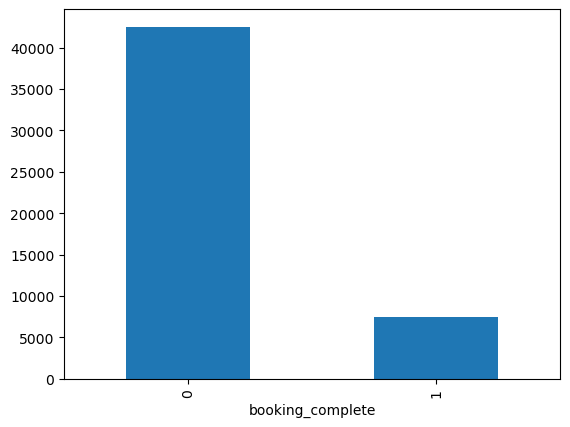

In [9]:
#Visualise distributions to understand customer booking behaviour patterns

df["booking_complete"].value_counts().plot(kind="bar")

In [10]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [11]:
cat_cols = df.select_dtypes(include="object").columns

for c in cat_cols:
    print("\n", c)
    print(df[c].value_counts().head(10))


 sales_channel
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

 trip_type
trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

 flight_day
flight_day
Mon    8102
Wed    7674
Tue    7673
Thu    7424
Fri    6761
Sun    6554
Sat    5812
Name: count, dtype: int64

 route
route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
Name: count, dtype: int64

 booking_origin
booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64


## Feature Engineering

In [12]:
df["is_weekend"] = df["flight_day"].isin(["Sat","Sun"]).astype(int)

In [13]:
def hour_bucket(h):
    if h>=5 & h<12:
        return "Morning"
    if h>=12 & h<17:
        return "Afternoon"
    if h>=17 & h<21:
        return "Evening"
    else:
        return "Night"

df["flight_time_bucket"] = df["flight_hour"].apply(hour_bucket)

#### Route Split (origin and destination airports)

In [14]:
df["route_from"]=df["route"].str[:3]
df["route_to"]=df["route"].str[3:]

In [15]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets using stratified sampling to preserve class distribution

target = "booking_complete"
X = df.drop(columns=[target])
y = df[target]

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(X_train.shape, X_test.shape)

(40000, 17) (10000, 17)


## Model Training

### Random Forest Classifier

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

num_cols = X.select_dtypes(exclude="object").columns
cat_cols = X.select_dtypes(include="object").columns

# Train Random Forest classifier to predict booking completion
# Random Forest is chosen for robustness and ability to handle mixed feature types

preprocess = ColumnTransformer(
    transformers = [
    ("cat", OneHotEncoder(handle_unknown="ignore"),cat_cols),
    ("num", "passthrough",num_cols)
]
)

In [17]:
model = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    n_jobs = 1,
    class_weight="balanced" #helps if target is imbalanced
)
clf = Pipeline(steps=[("preprocess",preprocess),("model",model)])

## Model Evaluation

### Cross-validation

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Evaluate model performance using stratified cross-validation

cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)

scoring = {
    "roc_auc": "roc_auc",
    "f1":"f1",
    "precision": "precision",
    "recall":"recall",
    "accuracy":"accuracy"
}

cv_results = cross_validate(clf,X,y,cv=cv,scoring=scoring,n_jobs = -1)

for k in scoring.keys():
    vals = cv_results[f"test_{k}"]
    print(f"{k}: mean = {vals.mean():.4f}, std = {vals.std():.4f}")

roc_auc: mean = 0.7869, std = 0.0017
f1: mean = 0.2151, std = 0.0071
precision: mean = 0.4968, std = 0.0164
recall: mean = 0.1373, std = 0.0054
accuracy: mean = 0.8501, std = 0.0013


### Classificaton Metrics and Confusion Matrix

In [19]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

clf.fit(X_train, y_train)

pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:,1]

print("Test ROC AUC:", roc_auc_score(y_test, proba))
print("\nClassification Report:\n", classification_report(y_test,pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,pred))

Test ROC AUC: 0.7909929378939637

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      8504
           1       0.52      0.13      0.20      1496

    accuracy                           0.85     10000
   macro avg       0.69      0.55      0.56     10000
weighted avg       0.81      0.85      0.81     10000


Confusion Matrix:
 [[8325  179]
 [1305  191]]


## Feature Importance

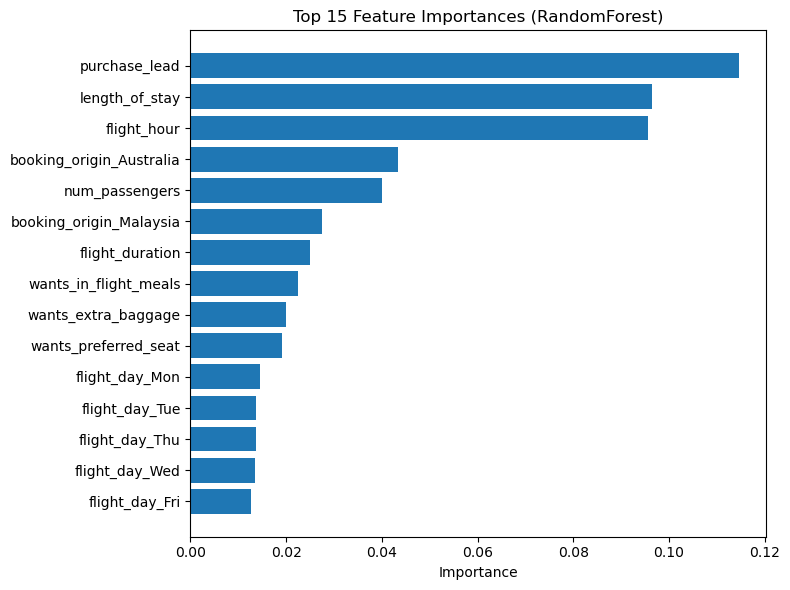

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Extract feature importance to identify key drivers of booking behaviour

ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([cat_feature_names, num_cols])

importances = clf.named_steps["model"].feature_importances_
idx = np.argsort(importances)[-15:]  # top 15 most imp features

plt.figure(figsize=(8, 6))
plt.barh(feature_names[idx], importances[idx])
plt.title("Top 15 Feature Importances (RandomForest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Business Insights

Key findings from the model:
- Customers booking longer trips are more likely to complete bookings
- Booking Channel significantly influences completion probability
- Previous travel history is a strong predictor of booking behaviour

These insights could help British Airways optimize marketing campaigns and booking funnels.